Import Required Libraries

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [27]:
df = pd.read_csv("D:\Marwan\ITI AI&ML\Week 16\ML1 & ML Flow Project\hand_landmarks_data.csv")

In [28]:
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [29]:
df.columns

Index(['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4',
       'x5', 'y5', 'z5', 'x6', 'y6', 'z6', 'x7', 'y7', 'z7', 'x8', 'y8', 'z8',
       'x9', 'y9', 'z9', 'x10', 'y10', 'z10', 'x11', 'y11', 'z11', 'x12',
       'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14', 'x15', 'y15',
       'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18', 'y18', 'z18',
       'x19', 'y19', 'z19', 'x20', 'y20', 'z20', 'x21', 'y21', 'z21', 'label'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [31]:
df.shape

(25675, 64)

There is no null values dataset is cleaned

In [32]:
df.isna().sum()

x1       0
y1       0
z1       0
x2       0
y2       0
        ..
z20      0
x21      0
y21      0
z21      0
label    0
Length: 64, dtype: int64

Data preprocessing

In [33]:
def preprocess_hand_landmarks(row):

    landmarks = row.values.reshape(21, 3)
    wrist = landmarks[0]
    landmarks[:, 0] -= wrist[0]
    landmarks[:, 1] -= wrist[1]
    mid_finger_tip = landmarks[12]
    scale_factor = np.linalg.norm(mid_finger_tip[:2])
    
    if scale_factor > 0:
        landmarks[:, :2] /= scale_factor
    
    return landmarks.flatten()

X_raw = df.drop('label', axis=1)
y = df['label']

X_processed = X_raw.apply(preprocess_hand_landmarks, axis=1, result_type='expand')

In [34]:
X_processed

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,0.0,0.0,-3.649205e-07,-0.169097,-0.328246,0.004224,-0.508248,-0.501843,0.005798,-0.846234,...,-0.013198,-1.266027,-0.058407,-0.020450,-1.533293,0.026072,-0.024577,-1.759842,0.074168,-0.026722
1,0.0,0.0,-2.345265e-07,-0.040618,-0.498120,-0.011102,0.191551,-0.982869,-0.021096,0.349889,...,-0.029042,1.397837,-0.121412,-0.038175,1.691695,-0.091952,-0.037336,1.966655,-0.086635,-0.036136
2,0.0,0.0,-2.417307e-07,0.172978,-0.420554,-0.000184,0.437913,-0.820949,-0.009687,0.621006,...,-0.041256,1.404373,0.187884,-0.044068,1.676609,0.247919,-0.040469,1.913833,0.270275,-0.038301
3,0.0,0.0,-1.233261e-07,-0.020056,-0.468103,-0.002824,0.070355,-0.911821,-0.008911,0.114792,...,-0.021804,1.280797,-0.094800,-0.027622,1.529073,-0.079763,-0.027863,1.738331,-0.086693,-0.027723
4,0.0,0.0,-1.622995e-07,-0.009611,-0.482677,-0.002884,0.111650,-1.075914,-0.008115,0.131602,...,-0.021623,1.327537,-0.331511,-0.025113,1.612488,-0.386821,-0.024087,1.849127,-0.464123,-0.023486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25670,0.0,0.0,4.323656e-07,0.114793,-0.193924,0.007132,0.098020,-0.383878,0.004480,-0.017284,...,-0.033732,-0.269009,-0.453257,-0.028861,-0.231440,-0.407954,-0.016911,-0.206572,-0.351443,-0.006697
25671,0.0,0.0,3.808555e-07,-0.125252,-0.180124,0.003778,-0.111937,-0.350482,-0.001519,-0.006770,...,-0.042692,0.261348,-0.444110,-0.043690,0.221988,-0.401492,-0.029510,0.197415,-0.341976,-0.015630
25672,0.0,0.0,5.912488e-07,0.138234,-0.145323,0.001354,0.146471,-0.315521,-0.001674,0.078645,...,-0.033021,-0.188357,-0.373106,-0.031740,-0.161311,-0.323239,-0.021970,-0.141828,-0.275497,-0.010803
25673,0.0,0.0,4.319564e-07,-0.075890,-0.182773,0.006174,-0.025361,-0.356612,0.001893,0.096384,...,-0.044705,0.372312,-0.382523,-0.046297,0.348274,-0.321332,-0.032800,0.302285,-0.274486,-0.020277


There is 18 different classes

In [35]:
y

0                   call
1                   call
2                   call
3                   call
4                   call
              ...       
25670    two_up_inverted
25671    two_up_inverted
25672    two_up_inverted
25673    two_up_inverted
25674    two_up_inverted
Name: label, Length: 25675, dtype: object

In [36]:
y.unique()

array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
       'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
       'three', 'three2', 'two_up', 'two_up_inverted'], dtype=object)

In [37]:
len(y.unique())

18

Dataset is balanced 

In [38]:
y.value_counts()

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

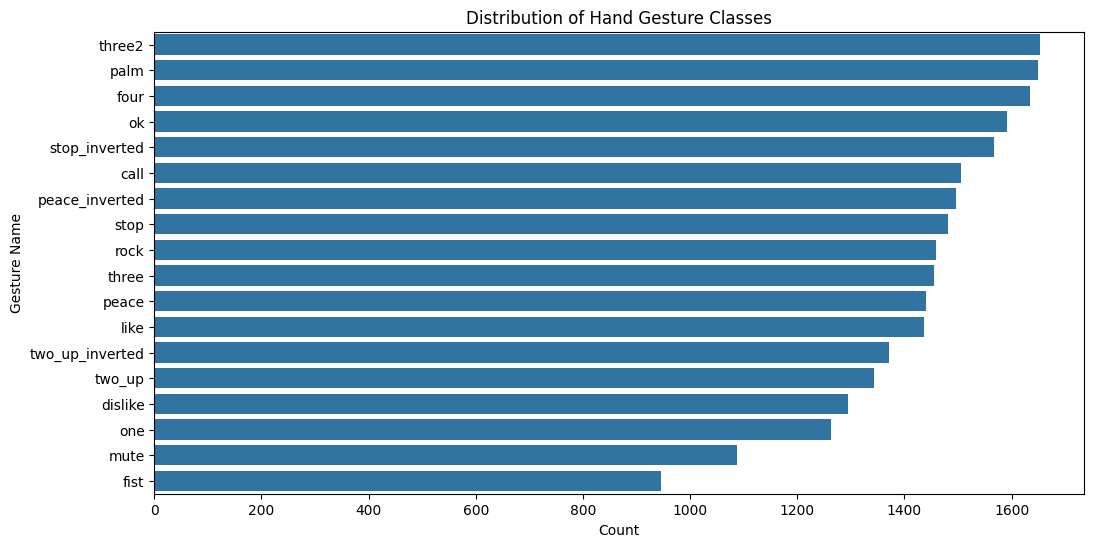

In [39]:
plt.figure(figsize=(12, 6))
sns.countplot(y=df['label'], order=df['label'].value_counts().index)
plt.title("Distribution of Hand Gesture Classes")
plt.xlabel("Count")
plt.ylabel("Gesture Name")
plt.show()

Visualization of each class shape

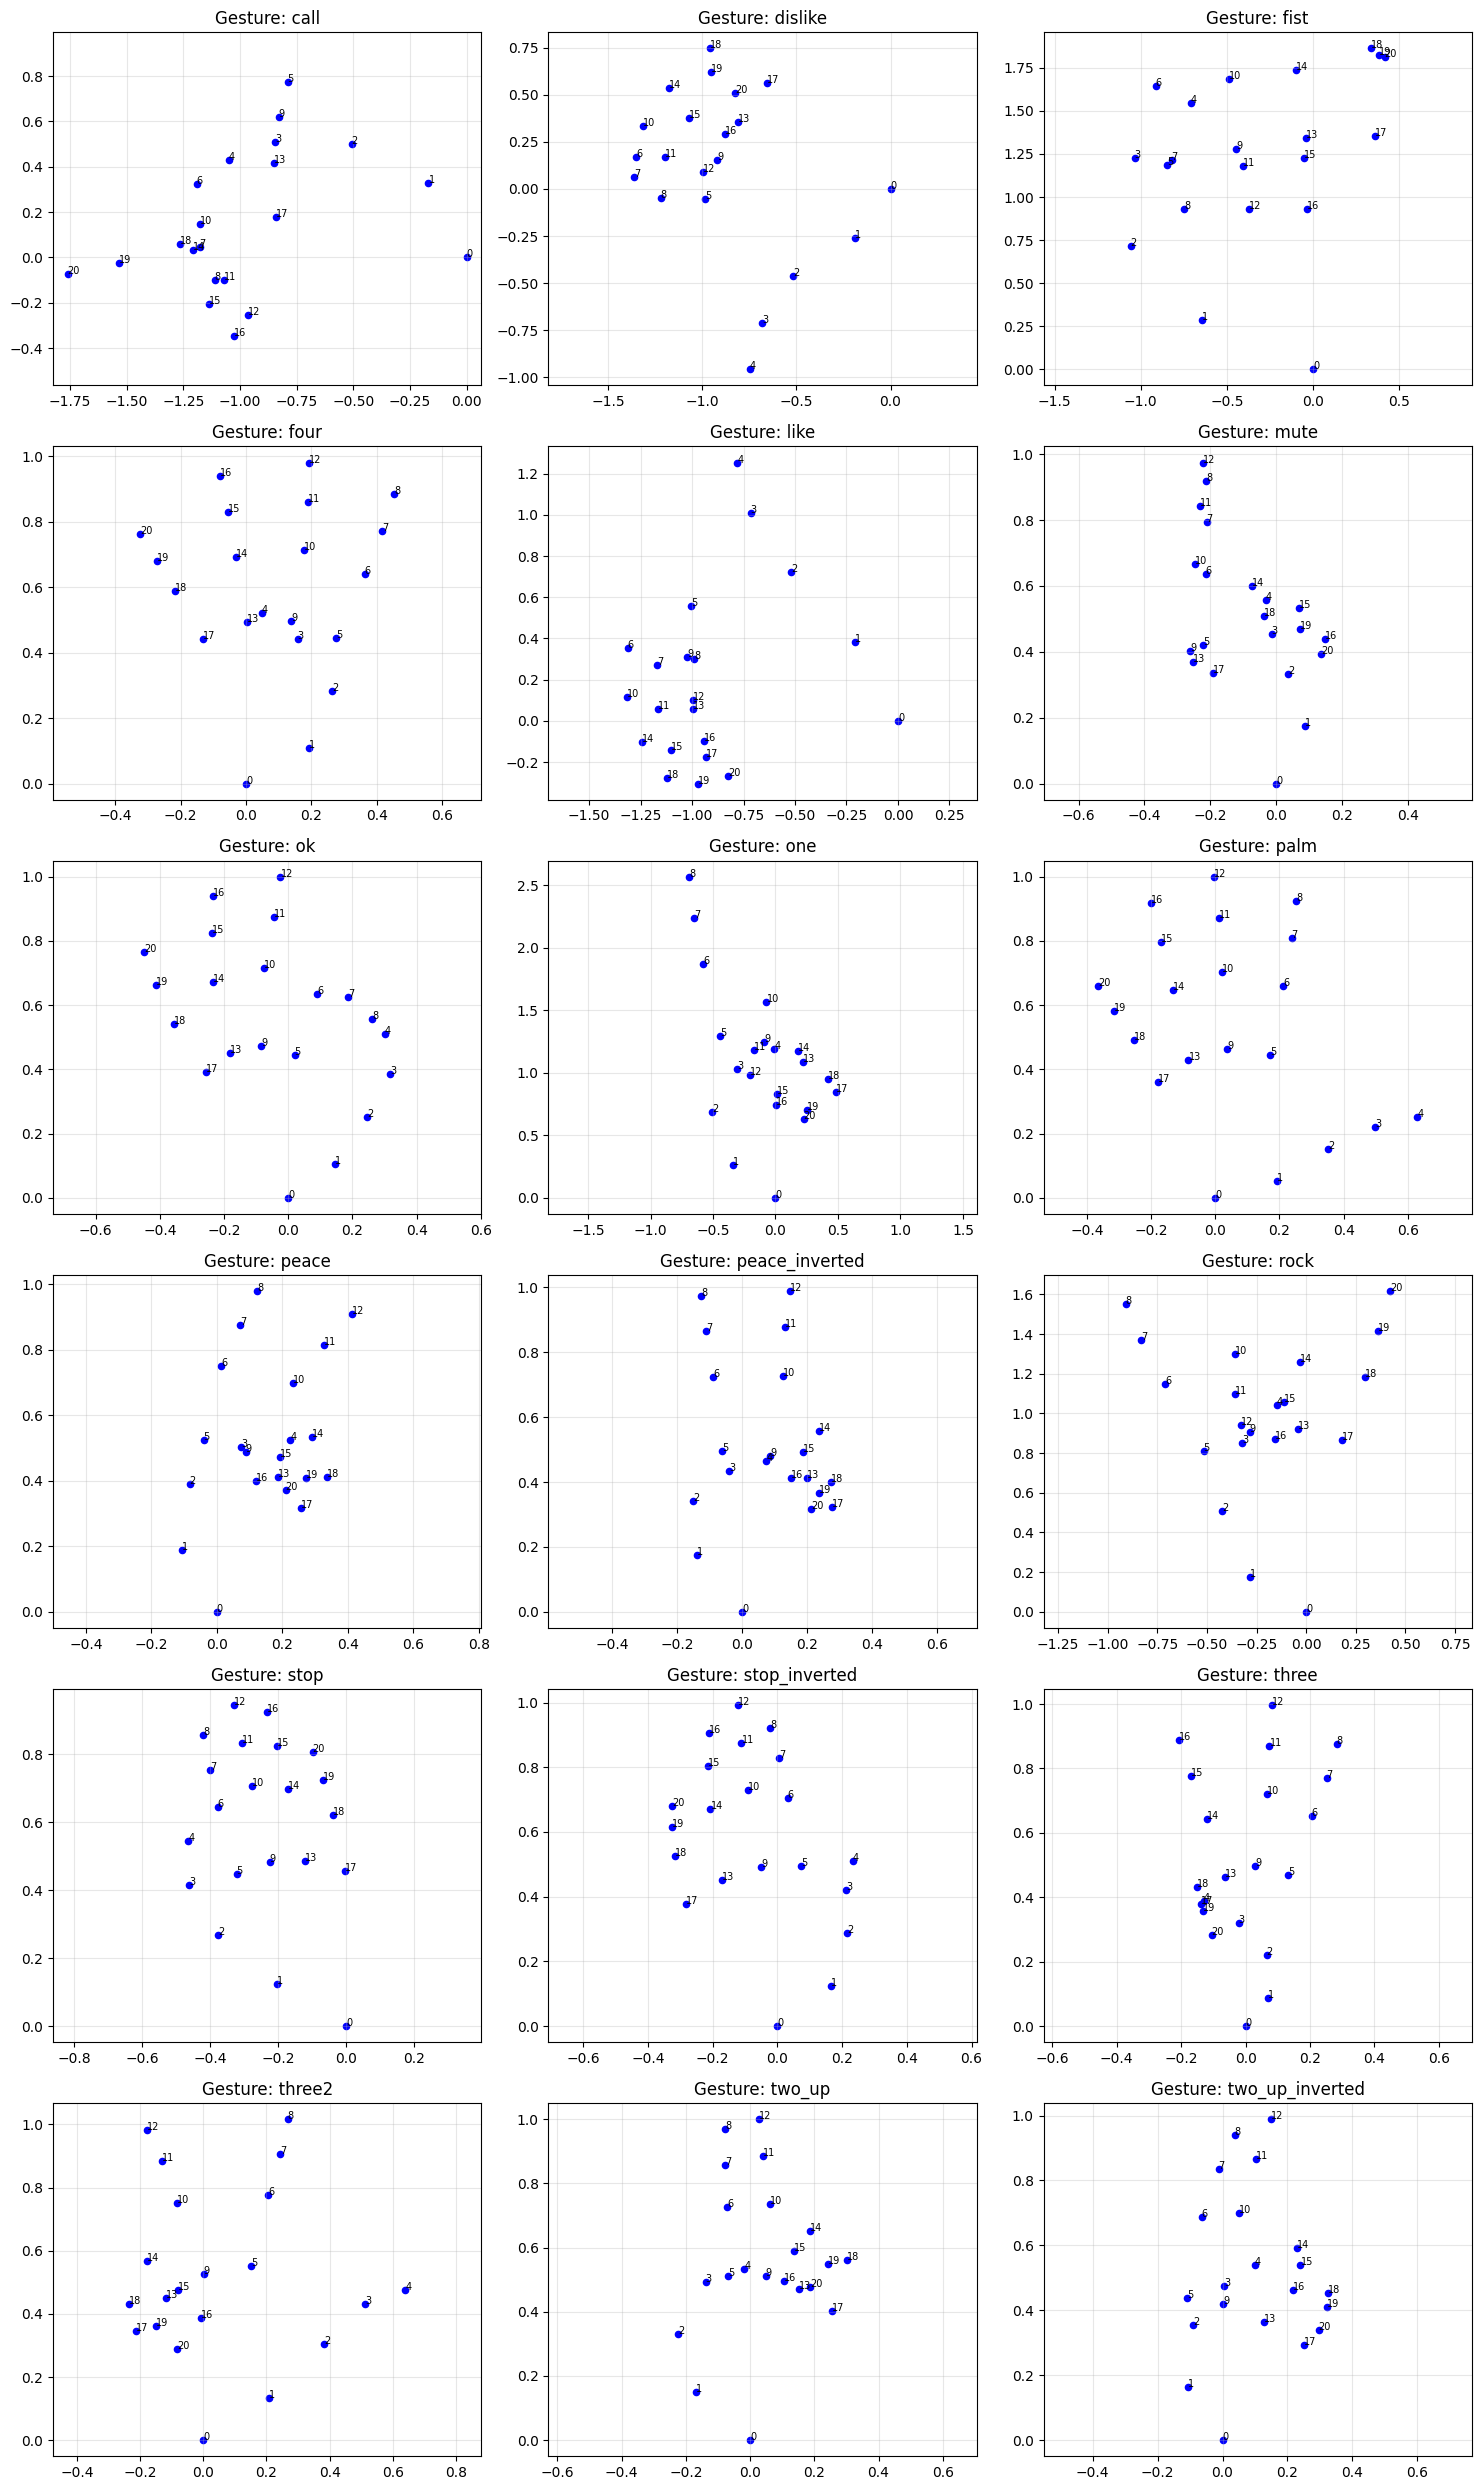

In [40]:
def plot_all_gestures(df):
    classes = df['label'].unique()
    num_classes = len(classes)
    fig, axes = plt.subplots(6, 3, figsize=(15, 25))
    axes = axes.flatten()

    for i, gesture in enumerate(classes):
        sample = df[df['label'] == gesture].iloc[0, :-1].values
        landmarks = sample.reshape(21, 3)
        
        wrist = landmarks[0]
        landmarks[:, 0] -= wrist[0]
        landmarks[:, 1] -= wrist[1]
        
        scale = np.linalg.norm(landmarks[12, :2])
        if scale > 0:
            landmarks[:, :2] /= scale

        ax = axes[i]
        ax.scatter(landmarks[:, 0], -landmarks[:, 1], c='blue', s=20) 
        
        for idx, (x, y, z) in enumerate(landmarks):
            ax.text(x, -y, str(idx), fontsize=7)
            
        ax.set_title(f"Gesture: {gesture}")
        ax.axis('equal')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_all_gestures(df)

Data splitting 

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 20540
Testing samples: 5135


Logestic Regression Model

In [42]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average='weighted'),
    "recall": recall_score(y_test, y_pred, average='weighted'),
    "f1_score": f1_score(y_test, y_pred, average='weighted')
}

Logestic Regression Confusion Matrix

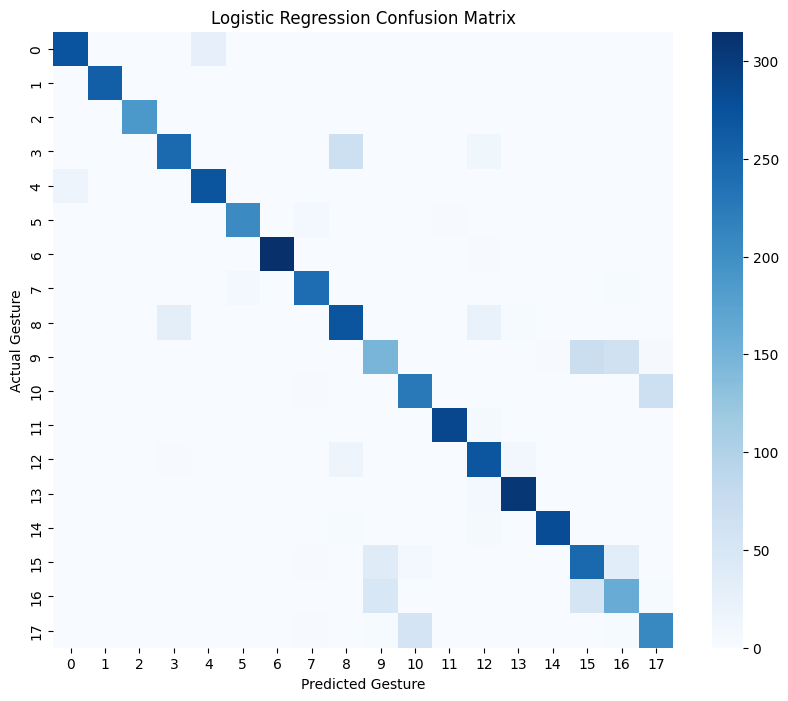

In [43]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.ylabel('Actual Gesture')
plt.xlabel('Predicted Gesture')
plt.show()

Decision Tree model

In [29]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_metrics = {
    "accuracy": dt_acc,
    "precision": precision_score(y_test, y_pred_dt, average='weighted'),
    "recall": recall_score(y_test, y_pred_dt, average='weighted'),
    "f1_score": f1_score(y_test, y_pred_dt, average='weighted')
}

print("Decision Tree Results:")
for metric, value in dt_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

Decision Tree Results:
Accuracy: 0.9507
Precision: 0.9509
Recall: 0.9507
F1_score: 0.9508


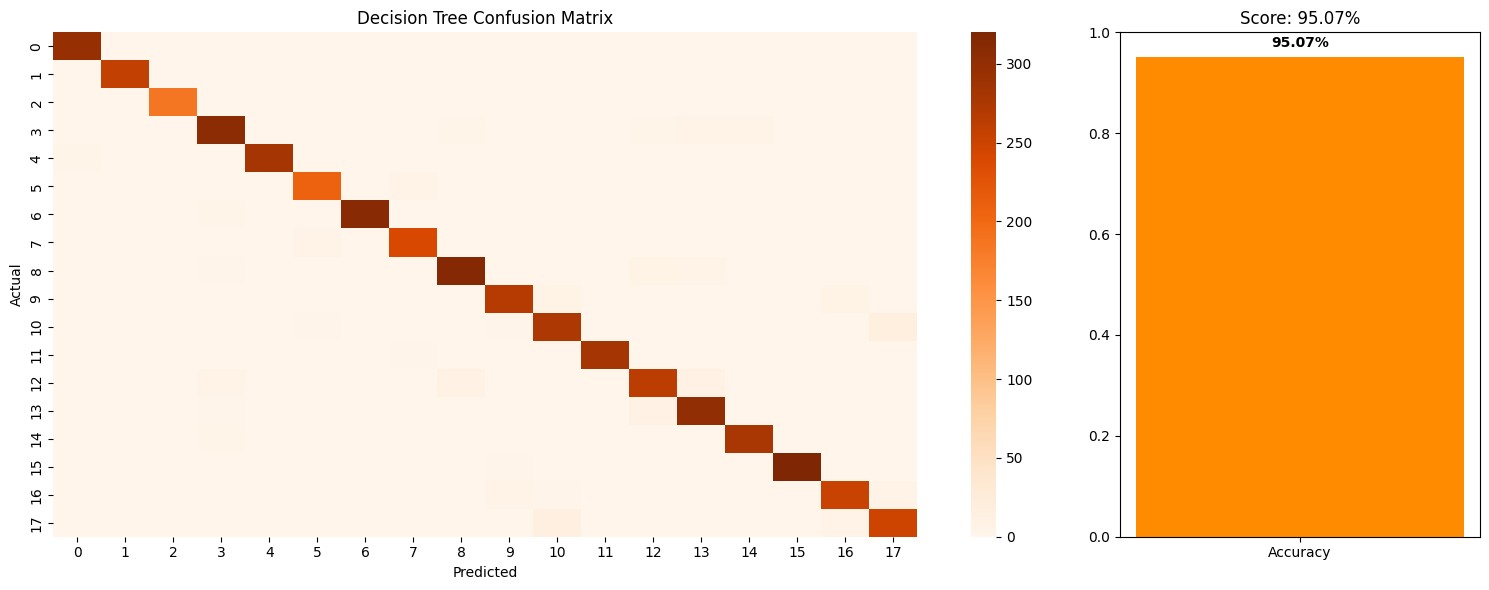

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 1]})

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=False, cmap='Oranges', ax=ax1)
ax1.set_title("Decision Tree Confusion Matrix")
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

ax2.bar(['Accuracy'], [dt_acc], color='darkorange')
ax2.set_ylim(0, 1)
ax2.set_title(f"Score: {dt_acc:.2%}")
for i, v in enumerate([dt_acc]):
    ax2.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Random Forest Model

In [31]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

rf_model = grid_search_rf.best_estimator_
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Accuracy: 0.9788


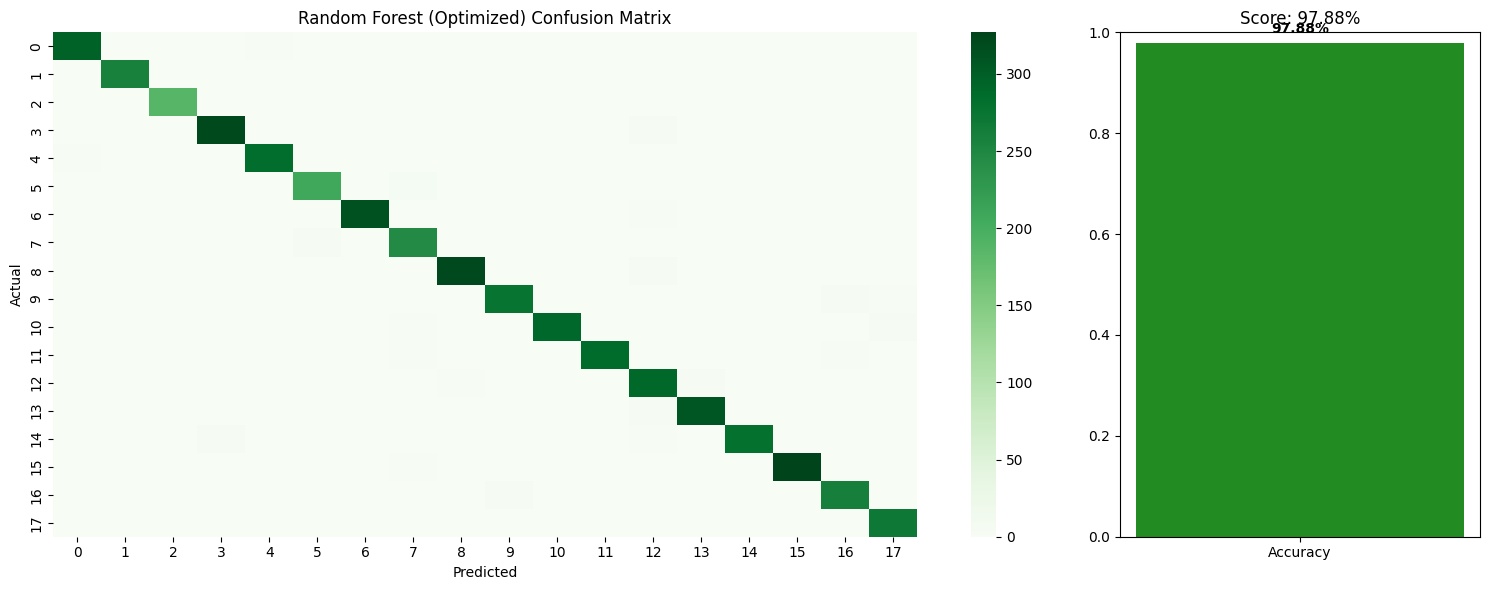

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 1]})
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=False, cmap='Greens', ax=ax1)
ax1.set_title(f"Random Forest (Optimized) Confusion Matrix")
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

ax2.bar(['Accuracy'], [rf_acc], color='forestgreen')
ax2.set_ylim(0, 1)
ax2.set_title(f"Score: {rf_acc:.2%}")
for i, v in enumerate([rf_acc]):
    ax2.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

SVM Model

In [35]:
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"SVM Results:")
print(f"Accuracy: {svm_acc:.4f}")

SVM Results:
Accuracy: 0.9334


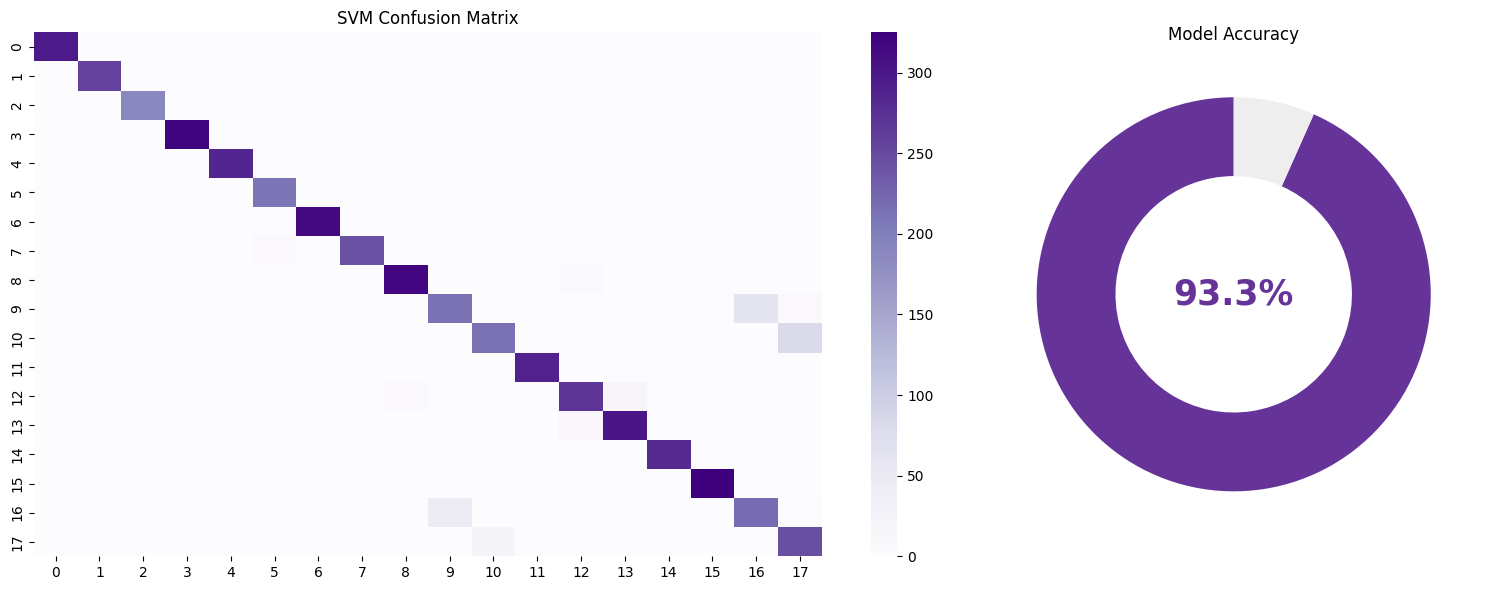

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=False, cmap='Purples', ax=ax1)
ax1.set_title("SVM Confusion Matrix")
colors = ['rebeccapurple', '#eeeeee']
ax2.pie([svm_acc, 1-svm_acc], labels=['', ''], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{svm_acc:.1%}", ha='center', va='center', fontsize=25, fontweight='bold', color='rebeccapurple')
ax2.set_title("Model Accuracy")

plt.tight_layout()
plt.show()

KNN Model

In [37]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {knn_acc:.4f}")

KNN Accuracy: 0.9772


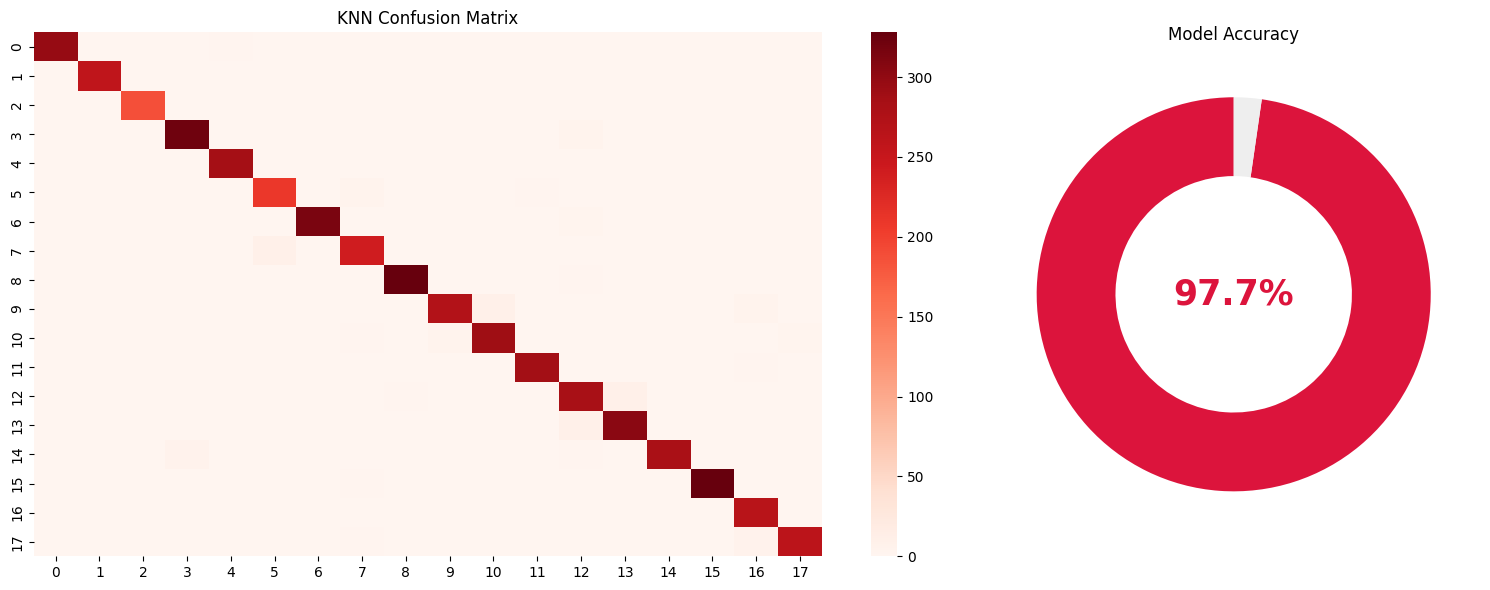

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=False, cmap='Reds', ax=ax1)
ax1.set_title("KNN Confusion Matrix")
colors = ['crimson', '#eeeeee']
ax2.pie([knn_acc, 1-knn_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{knn_acc:.1%}", ha='center', va='center', fontsize=25, fontweight='bold', color='crimson')
ax2.set_title("Model Accuracy")

plt.tight_layout()
plt.show()

Adaboost Model

In [43]:
base_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
ada_model = AdaBoostClassifier(estimator=base_dt, n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)

print(f"AdaBoost Accuracy: {ada_acc:.4f}")

AdaBoost Accuracy: 0.8582


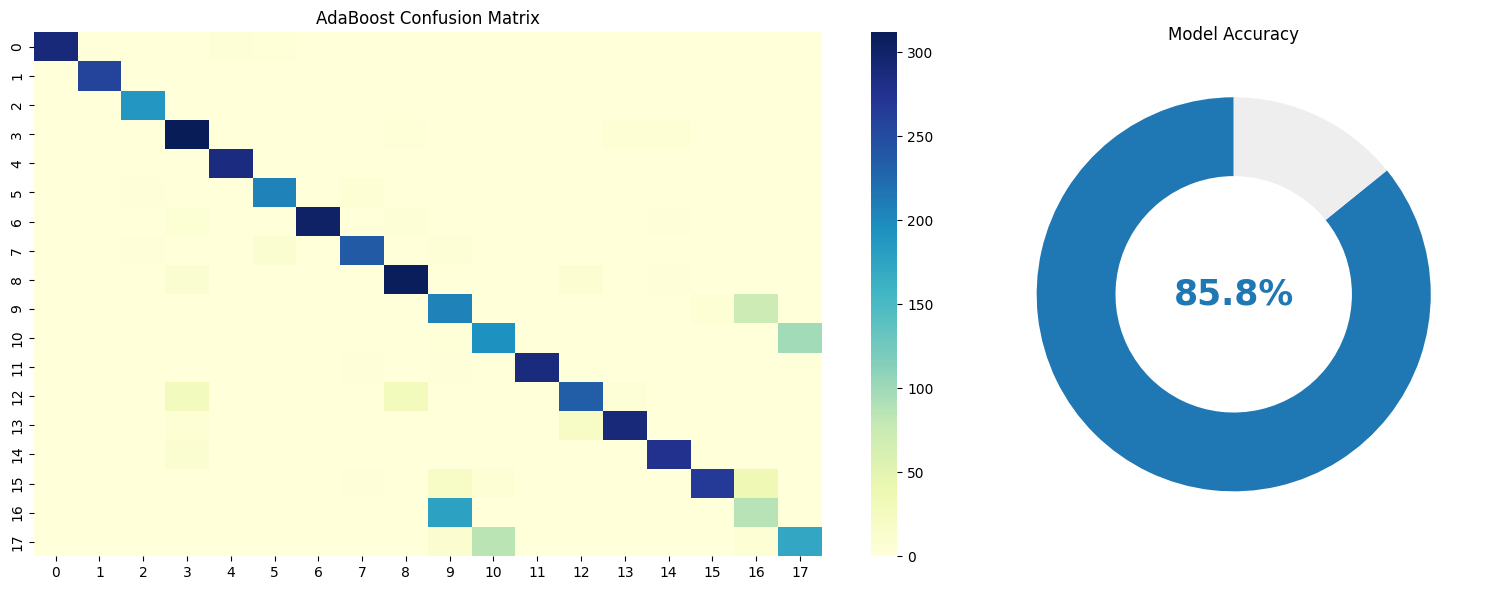

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=False, cmap='YlGnBu', ax=ax1)
ax1.set_title("AdaBoost Confusion Matrix")
colors = ['#1f77b4', '#eeeeee']
ax2.pie([ada_acc, 1-ada_acc], startangle=90, colors=colors, wedgeprops={'width': 0.4})
ax2.text(0, 0, f"{ada_acc:.1%}", ha='center', va='center', fontsize=25, fontweight='bold', color='#1f77b4')
ax2.set_title("Model Accuracy")
plt.tight_layout()
plt.show()